# Define Parameters

## Fixed Variable

In [1]:
L_1 = 1.5
L_2 = 9.5
L_4 = 2.8
L_EE = 3.2
z_base = 4.9

## Detected Variable

In [2]:
P_BL = [-13.41, 16.7557, 2.47]
P_BR = [-13.39, 17.44, 2.54]

P_T = P_BL.copy()

# Calculation

In [3]:
# !uv add numpy roboticstoolbox-python spatialmath-python plotly nbformat

In [3]:
import numpy as np
import math

## HELPER: Functions

In [4]:
def display_angle(angle_rad):
    
    angle_deg = math.degrees(angle_rad)

    # print(f"{angle_rad=}, {angle_deg=}")

    return f"{angle_rad=}, {angle_deg=}"

## Global Cabin Orientation, ϕ (phi) [rad]

$$ \phi = \tan^{-1} (\frac{y_{BR} - y_{BL}}{x_{BR} - x_{BL}}) + 90°$$

In [5]:
phi = np.arctan2((P_BR[1] - P_BL[1]), (P_BR[0] - P_BL[0])) + (np.pi/2)

display_angle(phi)

'angle_rad=np.float64(3.1123740241085995), angle_deg=178.32589584757108'

## ASSIST: Centrepoint of Cabin End, P<sub>C</sub>

$$x_C = x_T - L_{EE} \cos \phi$$
$$y_C = y_T - L_{EE} \sin \phi$$

In [6]:
x_C = P_T[0] - L_EE * np.cos(phi)
y_C = P_T[1] - L_EE * np.sin(phi)
z_C = None

P_C = [x_C, y_C, z_C]

P_C

[np.float64(-10.211365868116511), np.float64(16.662213688970233), None]

## θ<sub>1</sub> [rad]

$$90° + \theta_1 = \tan^{-1} (\frac{y_C}{x_C})$$
$$\therefore \theta_1 = \tan^{-1} (\frac{y_C}{x_C}) - 90°$$

In [7]:
theta_1 = np.arctan2(P_C[1], P_C[0]) - (np.pi/2)

display_angle(theta_1)

'angle_rad=np.float64(0.5498113581664623), angle_deg=31.50187035129396'

## θ<sub>4</sub> [rad]

$$ \phi = \theta_1 + \theta_4 + 90°$$

$$\therefore \theta_4 = \phi - \theta_1 - 90°$$

In [8]:
theta_4 = phi - theta_1 - (np.pi/2)

display_angle(theta_4)

'angle_rad=np.float64(0.9917663391472407), angle_deg=56.82402549627712'

## intermediate value: d<sub>z</sub>, y'<sub>C</sub> & y'<sub>T</sub>, d<sub>y'</sub>, L<sub>eff</sub>

$$y'_C = -x_C \sin{\theta_1} + y_C \cos{\theta_1}$$
$$y'_T = y_C + L_{EE} \cos{\theta_4}$$

In [9]:
y_prime_C = -P_C[0] * np.sin(theta_1) + P_C[1] * np.cos(theta_1)

y_prime_T = y_prime_C + L_EE * np.cos(theta_4)

y_prime_C, y_prime_T

(np.float64(19.542296638559193), np.float64(21.29337599853364))

$$ d_{y'} = y'_T - L1 $$

In [10]:
d_y_prime = y_prime_T - L_1

d_y_prime

np.float64(19.79337599853364)

$$ d_z = z_T - z_{Base} $$

In [10]:
d_z = P_T[2] - z_base

d_z

-2.43

$$ L_{eff} = \sqrt{(d_{y'})^2 + (d_z)^2}

In [13]:
L_eff = np.hypot(d_y_prime, d_z)

L_eff

np.float64(19.941981682353628)

## θ<sub>2</sub> [rad]

$$ \theta_2 = \tan^{-1}\frac{d_z}{d_{y'}} $$

In [14]:
theta_2 = np.arctan2(d_z, d_y_prime)

display_angle(theta_2)

angle_rad=np.float64(-0.12215707188407507), angle_deg=-6.999084656633713


## d<sub>3</sub> [m]

$$ d_3 = L_{eff} - L_2 - L_4 - L_{EE} \cos {\theta_4}

In [15]:
d_3 = L_eff - L_2 - L_4 - L_EE * np.cos(theta_4)

d_3

np.float64(5.890902322379179)

## COMPILATION

In [16]:
print(f"{L_1=}")
print(f"{L_2=}")
print(f"{L_4=}")
print(f"{L_EE=}")
print(f"{z_base=}")

print(f"{theta_1=}")
print(f"{theta_2=}")
print(f"{d_3=}")
print(f"{theta_4=}")

L_1=1.5
L_2=9.5
L_4=2.8
L_EE=3.2
z_base=4.9
theta_1=np.float64(0.5498113581664623)
theta_2=np.float64(-0.12215707188407507)
d_3=np.float64(5.890902322379179)
theta_4=np.float64(0.9917663391472407)


In [84]:
print("Computed Joint Parameters:")
print("theta_1 =", display_angle(theta_1).split("angle_deg=")[-1])
print("theta_2 =", display_angle(theta_2).split("angle_deg=")[-1])
print("d_3 =", d_3)
print("theta_4 =", display_angle(theta_4).split("angle_deg=")[-1])

Computed Joint Parameters:
theta_1 = 31.50187035129396
theta_2 = -6.999084656633713
d_3 = 5.890902322379179
theta_4 = 56.82402549627712


# VISUALISATION

In [91]:
import matplotlib.pyplot as plt

def rotz(theta):
    """Rotation matrix about Z axis"""
    return np.array([
        [np.cos(theta), -np.sin(theta), 0, 0],
        [np.sin(theta),  np.cos(theta), 0, 0],
        [0,              0,             1, 0],
        [0,              0,             0, 1]
    ])

def roty(theta):
    """Rotation matrix about X axis"""
    return np.array([
        [ np.cos(theta), 0, np.sin(theta), 0],
        [ 0            , 1, 0,             0],
        [-np.sin(theta), 0, np.cos(theta), 0],
        [0,              0, 0,             1]
    ])

def rotx(theta):
    """Rotation matrix about X axis"""
    return np.array([
        [1, 0,             0,              0],
        [0, np.cos(theta), -np.sin(theta), 0],
        [0, np.sin(theta),  np.cos(theta), 0],
        [0, 0,             0,              1]
    ])

def transl(x, y, z):
    """Translation matrix"""
    return np.array([
        [1, 0, 0, x],
        [0, 1, 0, y],
        [0, 0, 1, z],
        [0, 0, 0, 1]
    ])

# Initial position (origin)
points = [np.array([0, 0, 0, 1])]  # world origin

# Move up by z_base
T = transl(0, 0, z_base)
points.append(T @ np.array([0, 0, 0, 1]))

# Rotate about Z (θ1), move L_1 along Y in rotated frame
T = T @ rotz(theta_1)
T = T @ transl(0, L_1, 0)
points.append(T @ np.array([0, 0, 0, 1]))

# Rotate about X (θ2), move L_2 along Y in new frame
T = T @ rotx(theta_2) 
T = T @ transl(0, L_2, 0)
points.append(T @ np.array([0, 0, 0, 1]))

# Prismatic joint: move d_3 along Y of current frame
T = T @ transl(0, d_3, 0)
points.append(T @ np.array([0, 0, 0, 1]))

# Link 4: move L_4 along Y of current frame
T = T @ transl(0, L_4, 0)
points.append(T @ np.array([0, 0, 0, 1]))

# Final joint: Rotate about Z (θ4), move L_4 along Y of new frame)
T = T @ rotz(theta_4)
T = T @ transl(0, L_EE, 0)
points.append(T @ np.array([0, 0, 0, 1]))

# Extract xyz coordinates
points = np.array(points)
xs, ys, zs = points[:, 0], points[:, 1], points[:, 2]


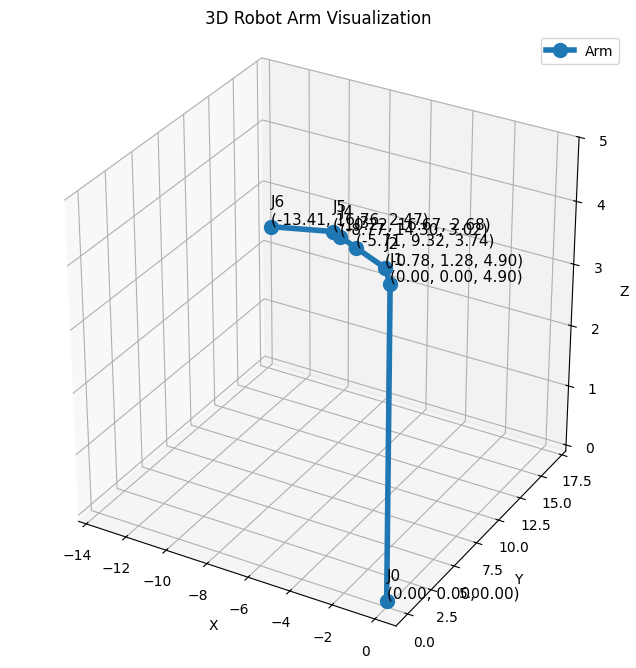

In [92]:
# 3D Plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, ys, zs, 'o-', linewidth=4, markersize=10, label='Arm')
for i, (xi, yi, zi) in enumerate(zip(xs, ys, zs)):
    label = f'J{i}\n({xi:.2f}, {yi:.2f}, {zi:.2f})'
    ax.text(xi, yi, zi, label, fontsize=11, ha='left', va='bottom')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Robot Arm Visualization')
ax.legend()
ax.grid(True)
ax.set_box_aspect([1,1,1])  # Equal aspect ratio for axes
plt.show()

In [97]:
import plotly.graph_objects as go

labels = [f'J{i}<br>({x:.2f},{y:.2f},{z:.2f})' for i, (x, y, z) in enumerate(zip(xs, ys, zs))]

fig = go.Figure()

# Add robot arm as a 3D line
fig.add_trace(go.Scatter3d(
    x=xs, y=ys, z=zs,
    mode='lines+markers+text',
    text=labels,
    marker=dict(size=6, color='blue'),
    line=dict(width=6, color='royalblue'),
    textposition='top right'
))

fig.update_layout(
    title='Interactive 3D Robot Arm',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='cube'
    ),
    showlegend=False,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [100]:
def Rz(theta):
    """Rotation matrix around Z-axis."""
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0,              0,             1]
    ])

def Rx(theta):
    """Rotation matrix around X-axis."""
    return np.array([
        [1, 0,            0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta),  np.cos(theta)]
    ])


def forward_kinematics(theta1, theta2, theta4, 
                       Z_base, L1, L2, d3, L4, EE_offset):
    # Base position
    p = np.array([0, 0, Z_base])

    # After first joint
    p += Rz(theta1).dot(np.array([0, L1, 0]))

    # After second joint
    p += Rx(theta2).dot(np.array([0, L2 + d3 + L4, 0]))

    # After fourth joint (end effector)
    p += Rz(theta4).dot(np.array([0, EE_offset, 0]))

    return p


In [102]:
# # Example values (angles in radians, distances in meters)
# theta1 = np.deg2rad(30)    # 30 degrees to radians
# theta2 = np.deg2rad(45)    # 45 degrees to radians
# theta4 = np.deg2rad(15)    # 15 degrees to radians
# Z_base = 0.5
# L1 = 1.0
# L2 = 0.8
# d3 = 0.2
# L4 = 0.1
# EE_offset = 0.05

pee = forward_kinematics(theta_1, theta_2, theta_4, 
                         z_base, L_1, L_2, d_3, L_4, L_EE)
print("End-effector position:", pee)

End-effector position: [-3.4621699  21.08535953  2.68337513]
